
# Crypto common-drive event networks — V4 confirmatory

## Objective

This notebook tests whether market-wide common activity creates a low-rank inflation of inferred cross-asset self-excitation networks, while avoiding target leakage and separating:

1. **detectable common-drive aliasing**;
2. **critical-to-subcritical transitions**;
3. **structural point identification via zero witnesses**;
4. **shock-specific effects relative to matched controls**.

### Main V3 corrections

- The common drive is built **only from continuous covariates**. Event indicators \(Y\) are never used to estimate the drive.
- Leave-one-out drives exclude the target asset.
- Reference-only drives use BTC/ETH continuous activity for altcoins.
- Both contemporaneous and one-bin-lagged drives are tested.
- The bootstrap resamples event and covariate blocks, then **reconstructs filtered histories**.
- Shock windows are compared with several controls through
  \[
  D_{\rm shock}
  =
  \Delta\rho_{\rm shock}
  -
  \operatorname{median}_{c\in\mathcal C}\Delta\rho_c.
  \]
- Candidate labels distinguish robust deflation, suggestive deflation, false criticality, and non-identification.
- Algorithm 1 is reported only when its zero-witness conditions pass.

This remains an empirical audit of binned event-network persistence. It is not a full continuous-time Hawkes maximum-likelihood estimator.


## Confirmatory extension integrated in this notebook

The final section performs the manuscript-level inference with:

- \(B=500\) circular moving-block bootstrap replicates;
- \(N=500\) circular-shift null replicates;
- filtered histories reconstructed after every block resample;
- the exact same constrained network estimator used in the main V3 pipeline;
- equation-specific \(T\times K\) drive matrices;
- bootstrap confidence intervals for
  \[
  \operatorname{rank1share}(\widehat B_{\rm naive}-\widehat B_{\rm drive});
  \]
- a dimension-matched Gaussian-matrix null for the rank-one share;
- manuscript-ready CSV, Markdown and LaTeX tables.

The confirmatory routines deliberately do **not** use the simplified OLS hook from the
stand-alone draft script, because that would not reproduce the V3 estimates.


In [ ]:

from pathlib import Path
from datetime import datetime, timedelta
import io
import json
import math
import time
import warnings
import zipfile
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

# =============================================================================
# CONFIGURATION
# =============================================================================

QUICK_MODE = False
RUN_DOWNLOAD = True
FORCE_REDOWNLOAD = False
RANDOM_SEED = 20260713

# A final run should use at least 500 bootstrap replicates.
BOOTSTRAP_REPS = 40 if QUICK_MODE else 500
NULL_REPS = 20 if QUICK_MODE else 200
BOOTSTRAP_BLOCK_MINUTES = 180
MIN_EVENT_COUNT_PER_ASSET = 12

ROOT = Path.cwd()
DATA = ROOT / "crypto_common_drive_data_V3"
RAW = DATA / "raw_binance"
OUT = ROOT / "crypto_common_drive_outputs_V3"
TABLES = OUT / "tables"
FIG = OUT / "figures"
CACHE = OUT / "cache"

for p in [RAW, OUT, TABLES, FIG, CACHE]:
    p.mkdir(parents=True, exist_ok=True)

SYMBOLS_QUICK = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT"]
SYMBOLS_FULL = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "LTCUSDT", "LINKUSDT", "AVAXUSDT",
    "TRXUSDT", "DOTUSDT", "ATOMUSDT", "BCHUSDT", "ETCUSDT",
    "FILUSDT", "NEARUSDT", "UNIUSDT"
]
SYMBOLS = SYMBOLS_QUICK if QUICK_MODE else SYMBOLS_FULL

# Shock windows and several controls. The full run evaluates all windows.
WINDOWS_FULL = [
    {"name": "Terra_Luna", "kind": "shock", "start": "2022-05-09", "end": "2022-05-12"},
    {"name": "FTX_collapse", "kind": "shock", "start": "2022-11-08", "end": "2022-11-10"},
    {"name": "Banking_crypto", "kind": "shock", "start": "2023-03-10", "end": "2023-03-13"},
    {"name": "Control_2022_Aug_A", "kind": "control", "start": "2022-08-08", "end": "2022-08-10"},
    {"name": "Control_2022_Aug_B", "kind": "control", "start": "2022-08-22", "end": "2022-08-24"},
    {"name": "Control_2022_Oct", "kind": "control", "start": "2022-10-10", "end": "2022-10-12"},
    {"name": "Control_2023_Jan", "kind": "control", "start": "2023-01-16", "end": "2023-01-18"},
    {"name": "Control_2023_Feb", "kind": "control", "start": "2023-02-06", "end": "2023-02-08"},
]
WINDOWS = [
    next(w for w in WINDOWS_FULL if w["name"] == "FTX_collapse"),
    next(w for w in WINDOWS_FULL if w["name"] == "Control_2022_Aug_A"),
] if QUICK_MODE else WINDOWS_FULL

# Keep QUICK_MODE small but diagnostic. The full grid is intentionally broader.
DESIGN_GRID_QUICK = [
    dict(event_type="volume_burst", q=0.985, bin="1min", lags=60, half_life=10,
         drive_mode="loo_market_activity", drive_timing="contemporaneous"),
    dict(event_type="volume_burst", q=0.985, bin="1min", lags=60, half_life=10,
         drive_mode="loo_market_activity", drive_timing="lag1"),
    dict(event_type="volatility_burst", q=0.985, bin="1min", lags=60, half_life=10,
         drive_mode="loo_market_activity", drive_timing="contemporaneous"),
    dict(event_type="volatility_burst", q=0.985, bin="1min", lags=60, half_life=10,
         drive_mode="loo_market_activity", drive_timing="lag1"),
    dict(event_type="volume_burst", q=0.985, bin="1min", lags=60, half_life=10,
         drive_mode="btc_eth_reference", drive_timing="contemporaneous"),
]

DESIGN_GRID_FULL = []
for event_type in ["volume_burst", "volatility_burst", "combined_burst", "imbalance_burst"]:
    for q in [0.98, 0.985, 0.99]:
        for bin_size, lags, half_life in [("1min", 60, 10), ("5min", 36, 4)]:
            for drive_mode in ["loo_market_activity", "btc_eth_reference", "global_covariate_pca"]:
                for drive_timing in ["contemporaneous", "lag1"]:
                    DESIGN_GRID_FULL.append(dict(
                        event_type=event_type, q=q, bin=bin_size, lags=lags,
                        half_life=half_life, drive_mode=drive_mode,
                        drive_timing=drive_timing
                    ))

DESIGN_GRID = DESIGN_GRID_QUICK if QUICK_MODE else DESIGN_GRID_FULL

print("QUICK_MODE:", QUICK_MODE)
print("Symbols:", len(SYMBOLS), SYMBOLS)
print("Windows:", [w["name"] for w in WINDOWS])
print("Designs per window:", len(DESIGN_GRID))
print("Bootstrap reps:", BOOTSTRAP_REPS)


QUICK_MODE: True
Symbols: 5 ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
Windows: ['FTX_collapse', 'Control_2022_Aug_A']
Designs per window: 5
Bootstrap reps: 40


In [2]:

# =============================================================================
# UTILITIES
# =============================================================================

def date_range_inclusive(start, end):
    d0 = datetime.strptime(start, "%Y-%m-%d").date()
    d1 = datetime.strptime(end, "%Y-%m-%d").date()
    out = []
    d = d0
    while d <= d1:
        out.append(d.strftime("%Y-%m-%d"))
        d += timedelta(days=1)
    return out

def simple_table_markdown(df, index=False, floatfmt=".6g"):
    if df is None or len(df) == 0:
        return "_No rows._"
    df2 = df.reset_index() if index else df.copy()
    cols = list(df2.columns)
    lines = ["| " + " | ".join(map(str, cols)) + " |",
             "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in df2.iterrows():
        vals = []
        for x in row:
            if pd.isna(x):
                vals.append("")
            elif isinstance(x, (float, np.floating)):
                vals.append(format(float(x), floatfmt))
            else:
                vals.append(str(x))
        lines.append("| " + " | ".join(vals) + " |")
    return "\n".join(lines)

def safe_standardize_df(df):
    df = df.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    med = df.median(axis=0)
    mad = (df - med).abs().median(axis=0).replace(0.0, np.nan)
    z = (df - med) / (1.4826 * mad)
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-10, 10)

def first_pc_score(df):
    X = safe_standardize_df(df).to_numpy(dtype=float)
    if X.shape[1] == 0:
        return np.zeros(X.shape[0])
    X -= X.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    score = X @ vt[0]
    # Orient the score toward aggregate activity for interpretability.
    agg = X.mean(axis=1)
    if np.corrcoef(score, agg)[0, 1] < 0:
        score = -score
    score = (score - np.mean(score)) / (np.std(score) + 1e-12)
    return score

def spectral_radius(B):
    vals = np.linalg.eigvals(np.asarray(B, dtype=float))
    return float(np.max(np.abs(vals))) if len(vals) else np.nan

def rank1_share(A):
    s = np.linalg.svd(np.asarray(A, dtype=float), compute_uv=False)
    den = np.sum(s ** 2)
    return float((s[0] ** 2) / den) if den > 0 else np.nan

def exp_kernel_weights(lags, half_life):
    ell = np.arange(1, lags + 1)
    w = np.exp(-np.log(2.0) * ell / max(float(half_life), 1e-6))
    return w / (w.sum() + 1e-12)

def build_filtered_histories(Y, lags=60, half_life=10):
    Y = np.asarray(Y, dtype=float)
    T, K = Y.shape
    w = exp_kernel_weights(lags, half_life)
    H = np.zeros_like(Y, dtype=float)
    for ell in range(1, lags + 1):
        H[ell:] += w[ell - 1] * Y[:-ell]
    return H

def circular_shift_columns(Y, rng, min_shift=120):
    Y = np.asarray(Y)
    T, K = Y.shape
    out = np.empty_like(Y)
    for k in range(K):
        lo = min(min_shift, max(1, T // 4))
        shift = int(rng.integers(lo, max(lo + 1, T - lo)))
        out[:, k] = np.roll(Y[:, k], shift)
    return out


In [3]:

# =============================================================================
# BINANCE AGGREGATE TRADES
# =============================================================================

AGGTRADE_COLUMNS = [
    "agg_trade_id", "price", "quantity", "first_trade_id", "last_trade_id",
    "transact_time", "is_buyer_maker", "is_best_match"
]

def aggtrade_url(symbol, date_str):
    return (
        "https://data.binance.vision/data/spot/daily/aggTrades/"
        f"{symbol}/{symbol}-aggTrades-{date_str}.zip"
    )

def download_one_aggtrade(symbol, date_str, raw_dir=RAW, force=False, timeout=60):
    out = raw_dir / symbol / f"{symbol}-aggTrades-{date_str}.zip"
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists() and out.stat().st_size > 100 and not force:
        return out
    url = aggtrade_url(symbol, date_str)
    try:
        with urllib.request.urlopen(url, timeout=timeout) as response:
            out.write_bytes(response.read())
        return out
    except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as exc:
        print(f"Download failed: {symbol} {date_str}: {exc}")
        return None

def read_aggtrade_zip(path):
    if path is None or not Path(path).exists():
        return pd.DataFrame(columns=AGGTRADE_COLUMNS)
    with zipfile.ZipFile(path) as zf:
        names = [n for n in zf.namelist() if not n.endswith("/")]
        if not names:
            return pd.DataFrame(columns=AGGTRADE_COLUMNS)
        with zf.open(names[0]) as fh:
            df = pd.read_csv(fh, header=None, names=AGGTRADE_COLUMNS)
    for c in ["price", "quantity"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["transact_time"] = pd.to_numeric(df["transact_time"], errors="coerce")
    df = df.dropna(subset=["price", "quantity", "transact_time"])
    df["time"] = pd.to_datetime(df["transact_time"], unit="ms", utc=True)
    df["is_buyer_maker"] = df["is_buyer_maker"].astype(str).str.lower().eq("true")
    return df

def aggregate_symbol_day(symbol, date_str, bin_size="1min"):
    cache_file = CACHE / f"{symbol}_{date_str}_{bin_size}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    path = download_one_aggtrade(
        symbol, date_str, force=FORCE_REDOWNLOAD
    ) if RUN_DOWNLOAD else RAW / symbol / f"{symbol}-aggTrades-{date_str}.zip"

    raw = read_aggtrade_zip(path)
    if raw.empty:
        return pd.DataFrame()

    raw["quote_volume"] = raw["price"] * raw["quantity"]
    raw["signed_quote_volume"] = np.where(
        raw["is_buyer_maker"], -raw["quote_volume"], raw["quote_volume"]
    )
    raw = raw.set_index("time").sort_index()

    agg = raw.resample(bin_size).agg(
        price=("price", "last"),
        volume=("quantity", "sum"),
        quote_volume=("quote_volume", "sum"),
        signed_quote_volume=("signed_quote_volume", "sum"),
        n_trades=("agg_trade_id", "count"),
    )
    agg["price"] = agg["price"].ffill()
    agg[["volume", "quote_volume", "signed_quote_volume", "n_trades"]] = (
        agg[["volume", "quote_volume", "signed_quote_volume", "n_trades"]].fillna(0.0)
    )
    agg["logret"] = np.log(agg["price"]).diff().fillna(0.0)
    agg["abs_logret"] = agg["logret"].abs()
    agg["imbalance"] = agg["signed_quote_volume"] / (agg["quote_volume"] + 1e-12)
    agg["abs_imbalance_x_volume"] = agg["imbalance"].abs() * agg["quote_volume"]
    agg["symbol"] = symbol
    agg = agg.reset_index()
    agg.to_parquet(cache_file, index=False)
    return agg

def load_window_panel(symbols, window, bin_size="1min"):
    frames = []
    for symbol in symbols:
        symbol_frames = []
        for date_str in date_range_inclusive(window["start"], window["end"]):
            x = aggregate_symbol_day(symbol, date_str, bin_size=bin_size)
            if not x.empty:
                symbol_frames.append(x)
        if symbol_frames:
            frames.append(pd.concat(symbol_frames, ignore_index=True))
        else:
            print("No usable data for", symbol, window["name"])
    if not frames:
        return pd.DataFrame()
    panel = pd.concat(frames, ignore_index=True)
    return panel.sort_values(["time", "symbol"]).reset_index(drop=True)


In [4]:

# =============================================================================
# FEATURES, EVENTS, AND LEAKAGE-FREE DRIVES
# =============================================================================

def panel_to_wide_features(panel, symbols):
    feats = {}
    feature_names = [
        "volume", "quote_volume", "n_trades", "logret", "abs_logret",
        "imbalance", "abs_imbalance_x_volume"
    ]
    full_index = pd.DatetimeIndex(sorted(panel["time"].unique()))
    for feature in feature_names:
        wide = panel.pivot(index="time", columns="symbol", values=feature)
        wide = wide.reindex(index=full_index, columns=symbols)
        if feature == "price":
            wide = wide.ffill()
        else:
            wide = wide.fillna(0.0)
        feats[feature] = wide.sort_index()
    return feats

def build_events_from_features(feats, event_type="volume_burst", q=0.985):
    if event_type == "volume_burst":
        X = np.log1p(feats["quote_volume"])
    elif event_type == "volatility_burst":
        X = feats["abs_logret"]
    elif event_type == "imbalance_burst":
        X = np.log1p(feats["abs_imbalance_x_volume"])
    elif event_type == "combined_burst":
        zv = safe_standardize_df(np.log1p(feats["quote_volume"]))
        zr = safe_standardize_df(feats["abs_logret"])
        X = zv + zr
    else:
        raise ValueError(f"Unknown event_type: {event_type}")

    thresholds = X.quantile(q, axis=0)
    Y = X.gt(thresholds, axis=1).astype(float)
    return Y, thresholds

def continuous_activity_score(feats):
    """Asset-specific continuous activity; contains no event indicators."""
    z_volume = safe_standardize_df(np.log1p(feats["quote_volume"]))
    z_trades = safe_standardize_df(np.log1p(feats["n_trades"]))
    z_vol = safe_standardize_df(feats["abs_logret"])
    z_imb = safe_standardize_df(np.log1p(feats["abs_imbalance_x_volume"]))
    return (z_volume + z_trades + z_vol + z_imb) / 4.0

def build_drive_matrix(feats, symbols, mode="loo_market_activity"):
    """
    Returns a T x K matrix M. Column k is the drive used in equation k.
    No event indicator Y is used anywhere in this function.
    """
    activity = continuous_activity_score(feats).reindex(columns=symbols)
    T, K = activity.shape
    M = np.zeros((T, K), dtype=float)

    if mode == "loo_market_activity":
        A = activity.to_numpy(dtype=float)
        for k in range(K):
            other = np.delete(A, k, axis=1)
            M[:, k] = first_pc_score(pd.DataFrame(other, index=activity.index))

    elif mode == "global_covariate_pca":
        score = first_pc_score(activity)
        M[:] = score[:, None]

    elif mode == "btc_eth_reference":
        refs = [s for s in ["BTCUSDT", "ETHUSDT"] if s in symbols]
        if not refs:
            raise ValueError("btc_eth_reference requires BTCUSDT or ETHUSDT.")
        ref_features = []
        for name in ["quote_volume", "n_trades", "abs_logret", "abs_imbalance_x_volume"]:
            x = feats[name][refs].copy()
            if name in ["quote_volume", "n_trades", "abs_imbalance_x_volume"]:
                x = np.log1p(x)
            x.columns = [f"{name}_{c}" for c in x.columns]
            ref_features.append(x)
        ref_df = pd.concat(ref_features, axis=1)
        base_score = first_pc_score(ref_df)
        for k, symbol in enumerate(symbols):
            # For BTC and ETH equations, use the other reference where possible.
            if symbol in refs and len(refs) > 1:
                other_ref = [r for r in refs if r != symbol]
                local = []
                for name in ["quote_volume", "n_trades", "abs_logret", "abs_imbalance_x_volume"]:
                    x = feats[name][other_ref].copy()
                    if name in ["quote_volume", "n_trades", "abs_imbalance_x_volume"]:
                        x = np.log1p(x)
                    local.append(x)
                M[:, k] = first_pc_score(pd.concat(local, axis=1))
            else:
                M[:, k] = base_score
    else:
        raise ValueError(f"Unknown drive mode: {mode}")

    M = (M - M.mean(axis=0, keepdims=True)) / (M.std(axis=0, keepdims=True) + 1e-12)
    return pd.DataFrame(M, index=activity.index, columns=symbols)

def apply_drive_timing(M_df, timing):
    if timing == "contemporaneous":
        return M_df.copy()
    if timing == "lag1":
        return M_df.shift(1).fillna(0.0)
    raise ValueError(f"Unknown drive timing: {timing}")


In [5]:

# =============================================================================
# NETWORK ESTIMATION
# =============================================================================

try:
    from scipy.optimize import lsq_linear
except ImportError as exc:
    raise ImportError("This notebook requires scipy. Install with: pip install scipy") from exc

def fit_row_lsq(y, H, m=None, nonnegative_B=True, ridge=1e-8):
    y = np.asarray(y, dtype=float)
    H = np.asarray(H, dtype=float)
    n, k = H.shape

    if m is None:
        X = np.column_stack([np.ones(n), H])
        lower = np.r_[-np.inf, np.zeros(k)] if nonnegative_B else np.full(k + 1, -np.inf)
        upper = np.full(k + 1, np.inf)
    else:
        m = np.asarray(m, dtype=float).reshape(-1)
        X = np.column_stack([np.ones(n), H, m])
        lower = np.r_[-np.inf, np.zeros(k), -np.inf] if nonnegative_B else np.full(k + 2, -np.inf)
        upper = np.full(k + 2, np.inf)

    if ridge > 0:
        p = X.shape[1]
        penalty = np.sqrt(ridge) * np.eye(p)
        penalty[0, 0] = 0.0
        X_aug = np.vstack([X, penalty])
        y_aug = np.r_[y, np.zeros(p)]
    else:
        X_aug, y_aug = X, y

    fit = lsq_linear(X_aug, y_aug, bounds=(lower, upper), lsmr_tol="auto")
    coef = fit.x
    mu = float(coef[0])
    B_row = coef[1:1 + k]
    c = float(coef[-1]) if m is not None else np.nan
    resid = y - X @ coef
    return mu, B_row, c, resid

def fit_network(Y, H, M=None, nonnegative_B=True):
    Y = np.asarray(Y, dtype=float)
    H = np.asarray(H, dtype=float)
    K = Y.shape[1]
    B = np.zeros((K, K))
    mu = np.zeros(K)
    c = np.full(K, np.nan)
    residuals = np.zeros_like(Y)

    for z in range(K):
        mz = None if M is None else np.asarray(M)[:, z]
        mu[z], B[z], c[z], residuals[:, z] = fit_row_lsq(
            Y[:, z], H, m=mz, nonnegative_B=nonnegative_B
        )

    return {"mu": mu, "B": B, "c": c, "residuals": residuals}

def effective_design(Y_df, M_df, lags, half_life):
    Y = Y_df.to_numpy(dtype=float)
    M = M_df.to_numpy(dtype=float)
    H = build_filtered_histories(Y, lags=lags, half_life=half_life)
    start = int(lags)
    return Y[start:], H[start:], M[start:], Y_df.index[start:]

def residual_loading_diagnostics(residuals, M, c_hat):
    residuals = np.asarray(residuals, dtype=float)
    M = np.asarray(M, dtype=float)
    K = residuals.shape[1]

    # Residual spike ratio
    cov_r = np.cov(residuals, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_r)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
    spike_ratio = float(eigvals[0] / max(eigvals[1], 1e-12)) if K > 1 else np.nan

    # Alignment between estimated regression loading and residual PC1
    pc1 = eigvecs[:, 0]
    cvec = np.asarray(c_hat, dtype=float)
    cvec = cvec / (np.linalg.norm(cvec) + 1e-12)
    loading_alignment = float(abs(np.dot(cvec, pc1)))

    # Per-equation drive-history separation kappa = 1 - R2(m_z ~ H)
    kappas = []
    for z in range(K):
        mz = M[:, z]
        X = np.column_stack([np.ones(len(mz)), build_filtered_histories(
            np.eye(1)[np.zeros(len(mz), dtype=int)], lags=1, half_life=1
        )]) if False else None
        # Direct least-squares projection on the actual H is computed outside.
        kappas.append(np.nan)

    return {
        "spike_ratio": spike_ratio,
        "loading_alignment": loading_alignment,
        "residual_pc1": pc1,
        "residual_eigenvalues": eigvals,
    }

def compute_kappa_per_equation(H, M):
    H = np.asarray(H, dtype=float)
    M = np.asarray(M, dtype=float)
    X = np.column_stack([np.ones(len(H)), H])
    kappas = []
    for z in range(M.shape[1]):
        m = M[:, z]
        coef, *_ = np.linalg.lstsq(X, m, rcond=None)
        pred = X @ coef
        sse = np.sum((m - pred) ** 2)
        sst = np.sum((m - np.mean(m)) ** 2)
        r2 = 1.0 - sse / max(sst, 1e-12)
        kappas.append(max(0.0, 1.0 - r2))
    return np.asarray(kappas)


In [6]:

# =============================================================================
# BOOTSTRAP AND NULL AUDITS
# =============================================================================

def circular_block_indices(T, block_length, rng):
    block_length = max(2, min(int(block_length), T))
    idx = []
    while len(idx) < T:
        start = int(rng.integers(0, T))
        block = (start + np.arange(block_length)) % T
        idx.extend(block.tolist())
    return np.asarray(idx[:T], dtype=int)

def bootstrap_delta_rho(
    Y_full, M_full, lags, half_life, block_length, reps, seed=0
):
    """
    Resample full event/covariate blocks, then reconstruct H from Y*.
    This avoids carrying histories that are incompatible with bootstrap Y*.
    """
    rng = np.random.default_rng(seed)
    Y_full = np.asarray(Y_full, dtype=float)
    M_full = np.asarray(M_full, dtype=float)
    T = len(Y_full)
    rows = []
    B_naive_list = []
    B_drive_list = []

    for b in range(reps):
        ii = circular_block_indices(T, block_length, rng)
        Yb = Y_full[ii]
        Mb = M_full[ii]
        Hb = build_filtered_histories(Yb, lags=lags, half_life=half_life)
        sl = slice(lags, None)

        naive = fit_network(Yb[sl], Hb[sl], M=None)
        drive = fit_network(Yb[sl], Hb[sl], M=Mb[sl])

        rho_n = spectral_radius(naive["B"])
        rho_d = spectral_radius(drive["B"])
        rows.append({
            "rep": b,
            "rho_naive": rho_n,
            "rho_drive": rho_d,
            "delta_rho": rho_n - rho_d,
        })
        B_naive_list.append(naive["B"])
        B_drive_list.append(drive["B"])

    return (
        pd.DataFrame(rows),
        np.asarray(B_naive_list),
        np.asarray(B_drive_list),
    )

def time_shift_null_distribution(
    Y_full, M_full, lags, half_life, reps, seed=0
):
    """
    Destroy cross-asset lag alignment while preserving each marginal event train.
    The continuous drive is retained. Refit naive and drive-aware models.
    """
    rng = np.random.default_rng(seed)
    rows = []
    for b in range(reps):
        Ynull = circular_shift_columns(Y_full, rng, min_shift=max(10, lags))
        Hnull = build_filtered_histories(Ynull, lags=lags, half_life=half_life)
        sl = slice(lags, None)
        naive = fit_network(Ynull[sl], Hnull[sl], M=None)
        drive = fit_network(Ynull[sl], Hnull[sl], M=M_full[sl])
        rho_n = spectral_radius(naive["B"])
        rho_d = spectral_radius(drive["B"])
        rows.append({
            "rep": b,
            "rho_naive_null": rho_n,
            "rho_drive_null": rho_d,
            "delta_rho_null": rho_n - rho_d,
        })
    return pd.DataFrame(rows)

def summarize_bootstrap(boot):
    x = boot["delta_rho"].dropna().to_numpy()
    if len(x) == 0:
        return dict(
            delta_rho_boot_p025=np.nan, delta_rho_boot_p05=np.nan,
            delta_rho_boot_p50=np.nan, delta_rho_boot_p95=np.nan,
            delta_rho_boot_p975=np.nan, delta_rho_boot_pos_share=np.nan
        )
    return dict(
        delta_rho_boot_p025=float(np.quantile(x, 0.025)),
        delta_rho_boot_p05=float(np.quantile(x, 0.05)),
        delta_rho_boot_p50=float(np.quantile(x, 0.50)),
        delta_rho_boot_p95=float(np.quantile(x, 0.95)),
        delta_rho_boot_p975=float(np.quantile(x, 0.975)),
        delta_rho_boot_pos_share=float(np.mean(x > 0)),
    )


In [7]:

# =============================================================================
# ZERO-WITNESS / ALGORITHM 1 APPLICABILITY
# =============================================================================

def zero_witness_diagnostics(B, c, B_boot=None, qT=None, T_eff=None, symbols=None):
    B = np.asarray(B, dtype=float)
    K = B.shape[0]
    symbols = symbols or [f"node_{i}" for i in range(K)]
    c = np.asarray(c, dtype=float)

    # Sign normalization only; do not force negative loadings to be positive.
    if np.nanmedian(c) < 0:
        c = -c
    valid_c = np.abs(c) > 1e-8

    T_eff = int(T_eff or 1000)
    qT = float(qT or math.sqrt(2 * math.log(max(3, K * T_eff))))

    if B_boot is not None and len(B_boot) >= 10:
        se_B = np.nanstd(B_boot, axis=0, ddof=1)
    else:
        se_B = np.full_like(B, np.nan)

    rows = []
    g_hat = np.full(K, np.nan)
    applicable_cols = []

    for k in range(K):
        ratios = np.full(K, np.nan)
        ratio_se = np.full(K, np.nan)
        for z in range(K):
            if valid_c[z]:
                ratios[z] = B[z, k] / c[z]
                if np.isfinite(se_B[z, k]):
                    ratio_se[z] = se_B[z, k] / abs(c[z])

        finite = np.isfinite(ratios) & np.isfinite(ratio_se)
        if finite.sum() < 2:
            rows.append({
                "column": symbols[k],
                "n_valid": int(finite.sum()),
                "candidate_zero_count": 0,
                "delta_hat": np.nan,
                "tau_hat": np.nan,
                "separation_ratio": np.nan,
                "passes": False,
            })
            applicable_cols.append(False)
            continue

        tau = float(np.nanmedian(ratio_se[finite]))
        order = np.argsort(ratios[finite])
        rv = ratios[finite][order]

        # Estimate lower plateau and its separation from the next cluster.
        lower = rv[0]
        candidate = ratios <= lower + 2.0 * qT * max(tau, 1e-12)
        above = ratios[~candidate & np.isfinite(ratios)]
        delta = float(np.min(above) - lower) if len(above) else np.nan
        sep = delta / (4.0 * qT * max(tau, 1e-12)) if np.isfinite(delta) else np.nan
        passes = bool(np.isfinite(sep) and sep > 1.0 and candidate.sum() >= 1)

        if passes:
            g_hat[k] = float(np.nanmedian(ratios[candidate]))
        applicable_cols.append(passes)
        rows.append({
            "column": symbols[k],
            "n_valid": int(finite.sum()),
            "candidate_zero_count": int(candidate.sum()),
            "delta_hat": delta,
            "tau_hat": tau,
            "separation_ratio": sep,
            "passes": passes,
        })

    diag = pd.DataFrame(rows)
    alg1_applicable = bool(np.all(applicable_cols)) and np.all(np.isfinite(g_hat))
    B_alg1 = None
    rho_alg1 = np.nan

    if alg1_applicable:
        B_alg1 = B - np.outer(c, g_hat)
        B_alg1 = np.maximum(B_alg1, 0.0)
        rho_alg1 = spectral_radius(B_alg1)

    return {
        "table": diag,
        "g_hat": g_hat,
        "alg1_applicable": alg1_applicable,
        "B_alg1": B_alg1,
        "rho_alg1": rho_alg1,
        "pass_cols": int(np.sum(applicable_cols)),
        "min_separation": float(diag["separation_ratio"].min()) if diag["separation_ratio"].notna().any() else np.nan,
    }


In [8]:

# =============================================================================
# RUN ONE DESIGN
# =============================================================================

def run_design(panel, symbols, window, design, seed_offset=0):
    feats = panel_to_wide_features(panel, symbols)
    Y_df, thresholds = build_events_from_features(
        feats, event_type=design["event_type"], q=design["q"]
    )

    event_counts = Y_df.sum(axis=0)
    keep_symbols = event_counts[event_counts >= MIN_EVENT_COUNT_PER_ASSET].index.tolist()
    if len(keep_symbols) < 3:
        raise RuntimeError(
            f"Too few assets with >= {MIN_EVENT_COUNT_PER_ASSET} events: {keep_symbols}"
        )

    Y_df = Y_df[keep_symbols]
    feats_k = {name: df[keep_symbols] for name, df in feats.items()}
    M_df = build_drive_matrix(
        feats_k, keep_symbols, mode=design["drive_mode"]
    )
    M_df = apply_drive_timing(M_df, design["drive_timing"])

    Y_full = Y_df.to_numpy(dtype=float)
    M_full = M_df.to_numpy(dtype=float)
    H_full = build_filtered_histories(
        Y_full, lags=design["lags"], half_life=design["half_life"]
    )
    sl = slice(design["lags"], None)

    Y = Y_full[sl]
    H = H_full[sl]
    M = M_full[sl]

    naive = fit_network(Y, H, M=None)
    drive = fit_network(Y, H, M=M)

    rho_naive = spectral_radius(naive["B"])
    rho_drive = spectral_radius(drive["B"])
    delta_rho = rho_naive - rho_drive
    Delta = naive["B"] - drive["B"]

    kappas = compute_kappa_per_equation(H, M)
    loading_diag = residual_loading_diagnostics(
        drive["residuals"], M, drive["c"]
    )

    bins_per_minute = 1 if design["bin"] == "1min" else 1 / 5
    block_length = max(
        design["lags"] + 1,
        int(BOOTSTRAP_BLOCK_MINUTES * bins_per_minute)
    )

    boot, Bn_boot, Bd_boot = bootstrap_delta_rho(
        Y_full=Y_full,
        M_full=M_full,
        lags=design["lags"],
        half_life=design["half_life"],
        block_length=block_length,
        reps=BOOTSTRAP_REPS,
        seed=RANDOM_SEED + seed_offset,
    )
    boot_summary = summarize_bootstrap(boot)

    null_df = time_shift_null_distribution(
        Y_full=Y_full,
        M_full=M_full,
        lags=design["lags"],
        half_life=design["half_life"],
        reps=NULL_REPS,
        seed=RANDOM_SEED + 10000 + seed_offset,
    )
    null_p = float(
        (1 + np.sum(null_df["delta_rho_null"] >= delta_rho)) /
        (1 + len(null_df))
    )

    zw = zero_witness_diagnostics(
        B=naive["B"],
        c=drive["c"],
        B_boot=Bn_boot,
        T_eff=len(Y),
        symbols=keep_symbols,
    )

    row = {
        "window": window["name"],
        "window_kind": window["kind"],
        **design,
        "K": len(keep_symbols),
        "T_eff": len(Y),
        "events_total": int(Y.sum()),
        "min_events_asset": int(event_counts[keep_symbols].min()),
        "rho_naive": rho_naive,
        "rho_drive": rho_drive,
        "delta_rho": delta_rho,
        "critical_to_subcritical": bool(rho_naive >= 1.0 and rho_drive < 1.0),
        "rank1_delta": rank1_share(Delta),
        "kappa_median": float(np.median(kappas)),
        "kappa_min": float(np.min(kappas)),
        "spike_ratio": loading_diag["spike_ratio"],
        "loading_alignment": loading_diag["loading_alignment"],
        "null_p_ge_observed": null_p,
        "alg1_applicable": zw["alg1_applicable"],
        "rho_alg1": zw["rho_alg1"],
        "zero_witness_pass_cols": zw["pass_cols"],
        "zero_witness_min_sep": zw["min_separation"],
        **boot_summary,
    }

    details = {
        "symbols": keep_symbols,
        "Y_df": Y_df,
        "M_df": M_df,
        "thresholds": thresholds,
        "naive": naive,
        "drive": drive,
        "Delta": Delta,
        "kappas": kappas,
        "loading_diag": loading_diag,
        "boot_df": boot,
        "null_df": null_df,
        "B_naive_boot": Bn_boot,
        "B_drive_boot": Bd_boot,
        "zero_witness": zw,
    }
    return row, details


In [9]:

# =============================================================================
# EXECUTE GRID
# =============================================================================

all_rows = []
details_store = {}
panels_by_window_bin = {}

for w_idx, window in enumerate(WINDOWS):
    print("\n" + "=" * 80)
    print("WINDOW:", window["name"], window["kind"], window["start"], window["end"])
    print("=" * 80)

    for d_idx, design in enumerate(DESIGN_GRID):
        key_panel = (window["name"], design["bin"])
        if key_panel not in panels_by_window_bin:
            print("Loading panel:", key_panel)
            panels_by_window_bin[key_panel] = load_window_panel(
                SYMBOLS, window, bin_size=design["bin"]
            )

        panel = panels_by_window_bin[key_panel]
        if panel.empty:
            print("Skipping empty panel:", key_panel)
            continue

        design_id = (
            f"{window['name']}__{design['event_type']}__q{design['q']}__"
            f"{design['bin']}__L{design['lags']}__HL{design['half_life']}__"
            f"{design['drive_mode']}__{design['drive_timing']}"
        )
        print("\nRunning:", design_id)

        try:
            row, details = run_design(
                panel, SYMBOLS, window, design,
                seed_offset=1000 * w_idx + d_idx
            )
            row["design_id"] = design_id
            all_rows.append(row)
            details_store[design_id] = details
            print(
                f"rho {row['rho_naive']:.3f} -> {row['rho_drive']:.3f}; "
                f"delta={row['delta_rho']:.3f}; rank1={row['rank1_delta']:.3f}; "
                f"boot+={row['delta_rho_boot_pos_share']:.2f}; null_p={row['null_p_ge_observed']:.3f}"
            )
        except Exception as exc:
            print("FAILED:", design_id, repr(exc))

results = pd.DataFrame(all_rows)
if results.empty:
    raise RuntimeError("No designs completed. Check downloads, cache, and dependencies.")

results.to_csv(TABLES / "v3_design_results_raw.csv", index=False)
display(results.sort_values("delta_rho", ascending=False))



WINDOW: FTX_collapse shock 2022-11-08 2022-11-10
Loading panel: ('FTX_collapse', '1min')

Running: FTX_collapse__volume_burst__q0.985__1min__L60__HL10__loo_market_activity__contemporaneous
rho 0.884 -> 0.771; delta=0.113; rank1=0.827; boot+=1.00; null_p=0.048

Running: FTX_collapse__volume_burst__q0.985__1min__L60__HL10__loo_market_activity__lag1
rho 0.884 -> 0.770; delta=0.114; rank1=0.835; boot+=1.00; null_p=0.048

Running: FTX_collapse__volatility_burst__q0.985__1min__L60__HL10__loo_market_activity__contemporaneous
rho 0.833 -> 0.665; delta=0.168; rank1=0.691; boot+=1.00; null_p=0.048

Running: FTX_collapse__volatility_burst__q0.985__1min__L60__HL10__loo_market_activity__lag1
rho 0.833 -> 0.715; delta=0.118; rank1=0.761; boot+=1.00; null_p=0.048

Running: FTX_collapse__volume_burst__q0.985__1min__L60__HL10__btc_eth_reference__contemporaneous
rho 0.884 -> 0.770; delta=0.115; rank1=0.767; boot+=1.00; null_p=0.048

WINDOW: Control_2022_Aug_A control 2022-08-08 2022-08-10
Loading panel

,window,window_kind,event_type,q,bin,lags,half_life,drive_mode,drive_timing,K,...,rho_alg1,zero_witness_pass_cols,zero_witness_min_sep,delta_rho_boot_p025,delta_rho_boot_p05,delta_rho_boot_p50,delta_rho_boot_p95,delta_rho_boot_p975,delta_rho_boot_pos_share,design_id
7,Control_2022_Aug_A,control,volatility_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,NaN,0,NaN,0.267513,0.269682,0.386715,0.609974,0.623323,1.0,Control_2022_Aug_A__volatility_burst__q0.985__...
5,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,NaN,0,NaN,0.134247,0.147644,0.233331,0.348671,0.376350,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...
9,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,btc_eth_reference,contemporaneous,5,...,NaN,0,NaN,0.059556,0.063668,0.180446,0.245809,0.264787,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...
2,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,NaN,1,1.296812,0.030064,0.034389,0.197800,0.389866,0.414234,1.0,FTX_collapse__volatility_burst__q0.985__1min__...
6,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,NaN,0,NaN,0.059428,0.090202,0.166484,0.280287,0.297131,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...
3,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,NaN,0,0.731178,0.020637,0.025525,0.153399,0.263019,0.267959,1.0,FTX_collapse__volatility_burst__q0.985__1min__...
4,FTX_collapse,shock,volume_burst,0.985,1min,60,10,btc_eth_reference,contemporaneous,5,...,NaN,0,NaN,0.021719,0.028875,0.109947,0.217992,0.222046,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...
1,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,NaN,0,0.590481,0.032051,0.047238,0.125752,0.228426,0.290007,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...
8,Control_2022_Aug_A,control,volatility_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,NaN,0,NaN,0.036882,0.046010,0.107727,0.196833,0.247614,1.0,Control_2022_Aug_A__volatility_burst__q0.985__...
0,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,NaN,0,NaN,0.049911,0.052152,0.151877,0.252082,0.270546,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...


In [10]:

# =============================================================================
# CLASSIFICATION AND SHOCK-CONTROL CONTRASTS
# =============================================================================

def classify_design(row):
    if bool(row["critical_to_subcritical"]):
        if row["delta_rho_boot_p05"] > 0 and row["rank1_delta"] >= 0.60:
            return "false_criticality_candidate"
        return "critical_crossing_suggestive"

    robust = (
        row["delta_rho"] > 0
        and row["delta_rho_boot_p05"] > 0
        and row["rank1_delta"] >= 0.60
        and row["kappa_median"] >= 0.20
        and row["spike_ratio"] >= 1.50
        and row["null_p_ge_observed"] <= 0.10
    )
    suggestive = (
        row["delta_rho"] > 0
        and row["delta_rho_boot_pos_share"] >= 0.90
        and row["rank1_delta"] >= 0.50
        and row["kappa_median"] >= 0.20
    )

    if robust:
        return "robust_common_drive_deflation"
    if suggestive:
        return "suggestive_common_drive_deflation"
    return "no_robust_deflation"

results["evidence_class"] = results.apply(classify_design, axis=1)

match_cols = [
    "event_type", "q", "bin", "lags", "half_life",
    "drive_mode", "drive_timing"
]
controls = results[results["window_kind"] == "control"].copy()
shocks = results[results["window_kind"] == "shock"].copy()

if not controls.empty and not shocks.empty:
    control_summary = (
        controls.groupby(match_cols, dropna=False)["delta_rho"]
        .agg(control_delta_median="median", control_delta_mean="mean",
             control_delta_min="min", control_delta_max="max",
             n_controls="count")
        .reset_index()
    )
    shock_contrasts = shocks.merge(control_summary, on=match_cols, how="left")
    shock_contrasts["shock_minus_control_median"] = (
        shock_contrasts["delta_rho"] - shock_contrasts["control_delta_median"]
    )
else:
    shock_contrasts = pd.DataFrame()

results.to_csv(TABLES / "v3_design_results.csv", index=False)
shock_contrasts.to_csv(TABLES / "v3_shock_control_contrasts.csv", index=False)

candidate_results = results[
    results["evidence_class"].isin([
        "false_criticality_candidate",
        "critical_crossing_suggestive",
        "robust_common_drive_deflation",
        "suggestive_common_drive_deflation",
    ])
].copy()
candidate_results.to_csv(TABLES / "v3_candidate_designs.csv", index=False)

print("Evidence classes:")
display(results["evidence_class"].value_counts().rename_axis("class").to_frame("n"))
print("\nCandidate designs:")
display(candidate_results.sort_values(
    ["evidence_class", "delta_rho"], ascending=[True, False]
))
print("\nShock-control contrasts:")
display(shock_contrasts.sort_values(
    "shock_minus_control_median", ascending=False
) if not shock_contrasts.empty else shock_contrasts)


Evidence classes:


,n
class,
robust_common_drive_deflation,10



Candidate designs:


,window,window_kind,event_type,q,bin,lags,half_life,drive_mode,drive_timing,K,...,zero_witness_pass_cols,zero_witness_min_sep,delta_rho_boot_p025,delta_rho_boot_p05,delta_rho_boot_p50,delta_rho_boot_p95,delta_rho_boot_p975,delta_rho_boot_pos_share,design_id,evidence_class
7,Control_2022_Aug_A,control,volatility_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,0,NaN,0.267513,0.269682,0.386715,0.609974,0.623323,1.0,Control_2022_Aug_A__volatility_burst__q0.985__...,robust_common_drive_deflation
5,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,0,NaN,0.134247,0.147644,0.233331,0.348671,0.376350,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...,robust_common_drive_deflation
9,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,btc_eth_reference,contemporaneous,5,...,0,NaN,0.059556,0.063668,0.180446,0.245809,0.264787,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...,robust_common_drive_deflation
2,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,1,1.296812,0.030064,0.034389,0.197800,0.389866,0.414234,1.0,FTX_collapse__volatility_burst__q0.985__1min__...,robust_common_drive_deflation
6,Control_2022_Aug_A,control,volume_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0,NaN,0.059428,0.090202,0.166484,0.280287,0.297131,1.0,Control_2022_Aug_A__volume_burst__q0.985__1min...,robust_common_drive_deflation
3,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0,0.731178,0.020637,0.025525,0.153399,0.263019,0.267959,1.0,FTX_collapse__volatility_burst__q0.985__1min__...,robust_common_drive_deflation
4,FTX_collapse,shock,volume_burst,0.985,1min,60,10,btc_eth_reference,contemporaneous,5,...,0,NaN,0.021719,0.028875,0.109947,0.217992,0.222046,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation
1,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0,0.590481,0.032051,0.047238,0.125752,0.228426,0.290007,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation
8,Control_2022_Aug_A,control,volatility_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0,NaN,0.036882,0.046010,0.107727,0.196833,0.247614,1.0,Control_2022_Aug_A__volatility_burst__q0.985__...,robust_common_drive_deflation
0,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,0,NaN,0.049911,0.052152,0.151877,0.252082,0.270546,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation



Shock-control contrasts:


,window,window_kind,event_type,q,bin,lags,half_life,drive_mode,drive_timing,K,...,delta_rho_boot_p975,delta_rho_boot_pos_share,design_id,evidence_class,control_delta_median,control_delta_mean,control_delta_min,control_delta_max,n_controls,shock_minus_control_median
3,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0.267959,1.0,FTX_collapse__volatility_burst__q0.985__1min__...,robust_common_drive_deflation,0.114090,0.114090,0.114090,0.114090,1,0.003856
1,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,lag1,5,...,0.290007,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation,0.137156,0.137156,0.137156,0.137156,1,-0.022785
4,FTX_collapse,shock,volume_burst,0.985,1min,60,10,btc_eth_reference,contemporaneous,5,...,0.222046,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation,0.180176,0.180176,0.180176,0.180176,1,-0.065604
0,FTX_collapse,shock,volume_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,0.270546,1.0,FTX_collapse__volume_burst__q0.985__1min__L60_...,robust_common_drive_deflation,0.214434,0.214434,0.214434,0.214434,1,-0.101163
2,FTX_collapse,shock,volatility_burst,0.985,1min,60,10,loo_market_activity,contemporaneous,5,...,0.414234,1.0,FTX_collapse__volatility_burst__q0.985__1min__...,robust_common_drive_deflation,0.448872,0.448872,0.448872,0.448872,1,-0.280416


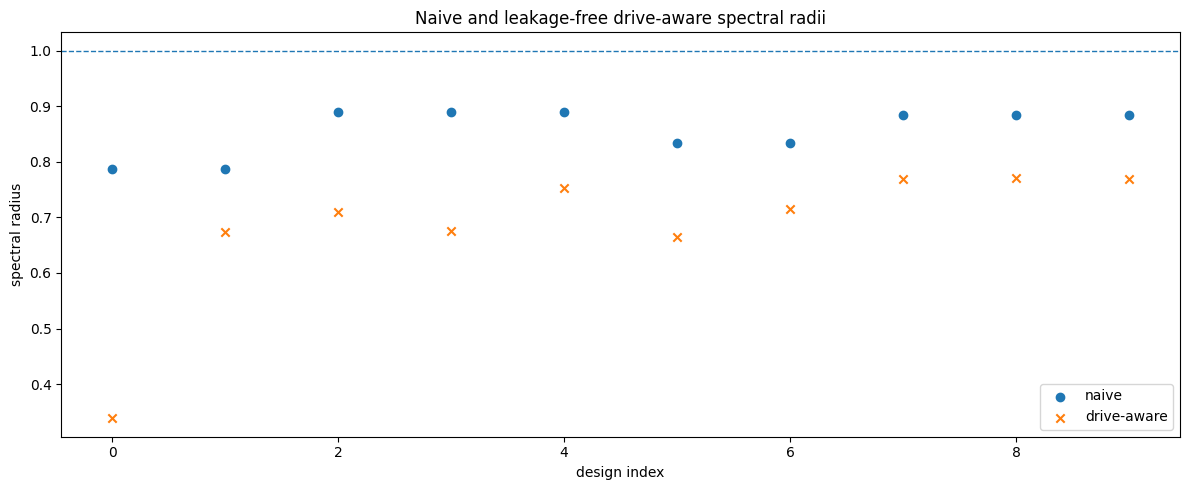

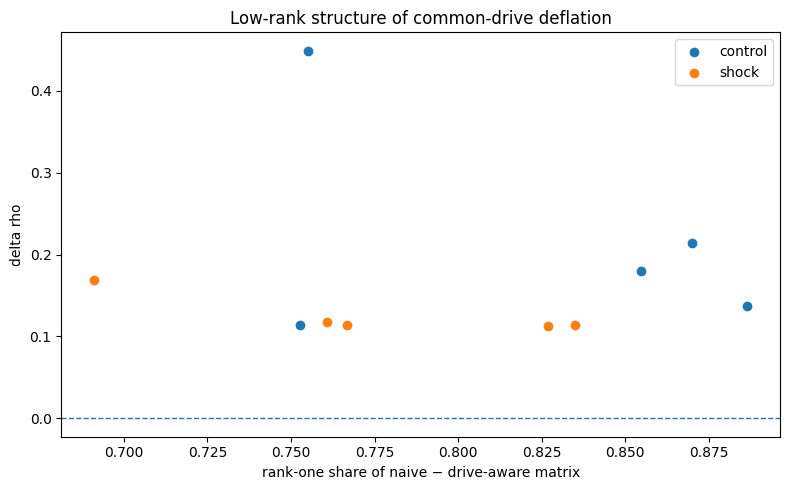

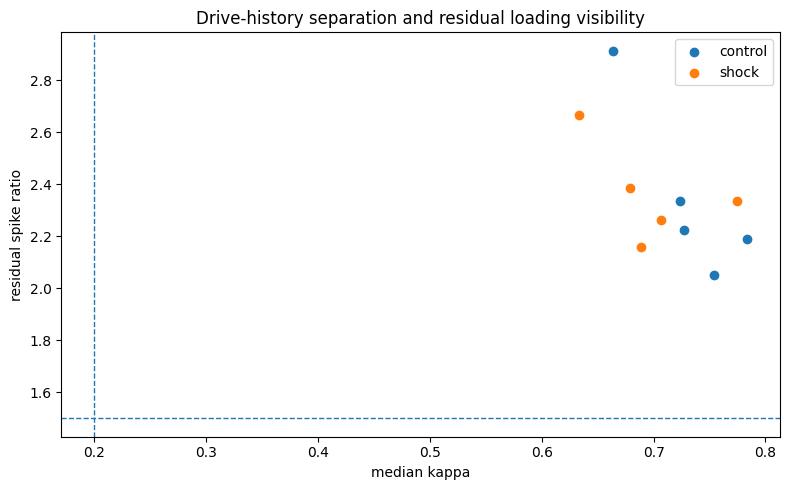

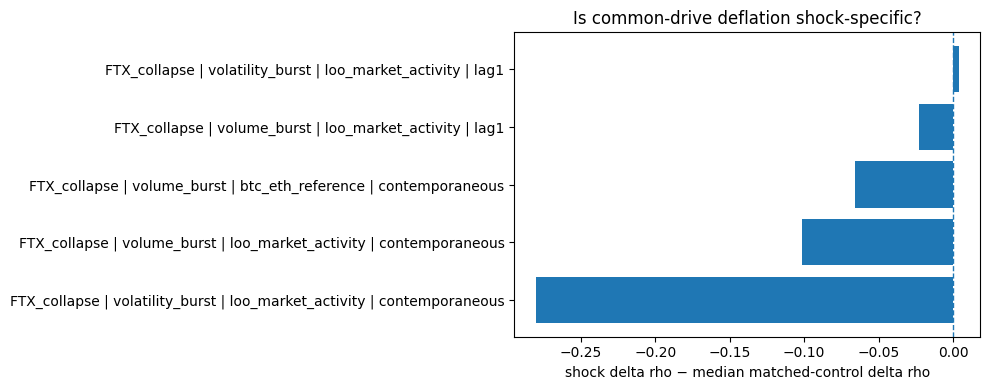

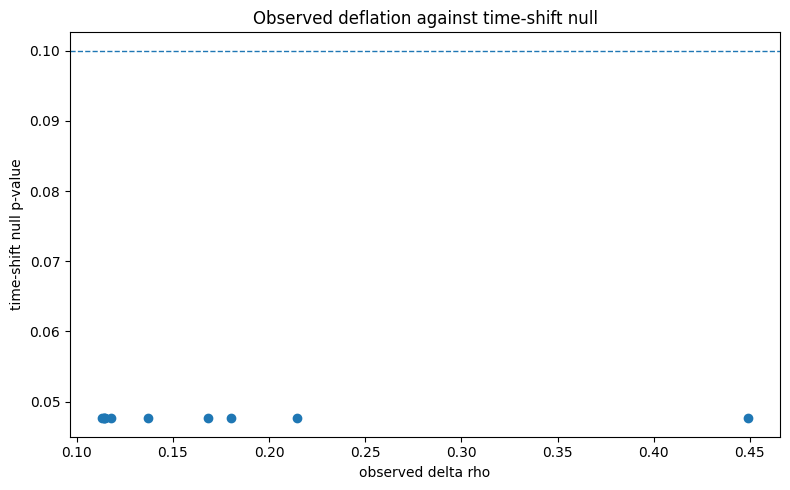

In [11]:

# =============================================================================
# FIGURES
# =============================================================================

plot_df = results.sort_values(
    ["window_kind", "window", "event_type", "drive_mode", "drive_timing"]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_df))
ax.scatter(x, plot_df["rho_naive"], marker="o", label="naive")
ax.scatter(x, plot_df["rho_drive"], marker="x", label="drive-aware")
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_ylabel("spectral radius")
ax.set_xlabel("design index")
ax.set_title("Naive and leakage-free drive-aware spectral radii")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig01_rho_naive_vs_drive_V3.png", dpi=220)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for kind, grp in results.groupby("window_kind"):
    ax.scatter(grp["rank1_delta"], grp["delta_rho"], label=kind)
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_xlabel("rank-one share of naive − drive-aware matrix")
ax.set_ylabel("delta rho")
ax.set_title("Low-rank structure of common-drive deflation")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig02_delta_rho_rank1_V3.png", dpi=220)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for kind, grp in results.groupby("window_kind"):
    ax.scatter(grp["kappa_median"], grp["spike_ratio"], label=kind)
ax.axvline(0.2, linestyle="--", linewidth=1)
ax.axhline(1.5, linestyle="--", linewidth=1)
ax.set_xlabel("median kappa")
ax.set_ylabel("residual spike ratio")
ax.set_title("Drive-history separation and residual loading visibility")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig03_kappa_spike_V3.png", dpi=220)
plt.show()

if not shock_contrasts.empty:
    sc = shock_contrasts.sort_values("shock_minus_control_median")
    labels = (
        sc["window"] + " | " + sc["event_type"] + " | " +
        sc["drive_mode"] + " | " + sc["drive_timing"]
    )
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(sc))))
    y = np.arange(len(sc))
    ax.barh(y, sc["shock_minus_control_median"])
    ax.axvline(0.0, linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel("shock delta rho − median matched-control delta rho")
    ax.set_title("Is common-drive deflation shock-specific?")
    fig.tight_layout()
    fig.savefig(FIG / "fig04_shock_control_contrast_V3.png", dpi=220)
    plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results["delta_rho"], results["null_p_ge_observed"])
ax.axhline(0.10, linestyle="--", linewidth=1)
ax.set_xlabel("observed delta rho")
ax.set_ylabel("time-shift null p-value")
ax.set_title("Observed deflation against time-shift null")
fig.tight_layout()
fig.savefig(FIG / "fig05_null_audit_V3.png", dpi=220)
plt.show()


Strongest design by delta rho:


,value
window,Control_2022_Aug_A
window_kind,control
event_type,volatility_burst
q,0.985
bin,1min
lags,60
half_life,10
drive_mode,loo_market_activity
drive_timing,contemporaneous
K,5



Zero-witness audit:


,column,n_valid,candidate_zero_count,delta_hat,tau_hat,separation_ratio,passes
0,BTCUSDT,5,5,NaN,5.023235,NaN,False
1,ETHUSDT,5,5,NaN,3.798220,NaN,False
2,BNBUSDT,5,5,NaN,0.183007,NaN,False
3,SOLUSDT,5,5,NaN,3.165330,NaN,False
4,XRPUSDT,5,5,NaN,3.051873,NaN,False



Bootstrap summary:


,rep,rho_naive,rho_drive,delta_rho
count,40.000000,40.000000,4.000000e+01,40.000000
mean,19.500000,0.726376,3.070224e-01,0.419353
std,11.690452,0.130214,1.141105e-01,0.120851
min,0.000000,0.328815,1.740960e-07,0.222230
25%,9.750000,0.695554,2.171293e-01,0.319707
50%,19.500000,0.769345,3.390400e-01,0.386715
75%,29.250000,0.798056,3.996720e-01,0.508558
max,39.000000,0.840407,4.843945e-01,0.696310



Time-shift null summary:


,rep,rho_naive_null,rho_drive_null,delta_rho_null
count,20.00000,20.000000,20.000000,20.000000
mean,9.50000,0.781078,0.780204,0.000874
std,5.91608,0.011328,0.010917,0.001975
min,0.00000,0.738357,0.741254,-0.002897
25%,4.75000,0.780706,0.777729,-0.000091
50%,9.50000,0.782056,0.781172,0.000510
75%,14.25000,0.786433,0.785675,0.002193
max,19.00000,0.796488,0.799178,0.005489


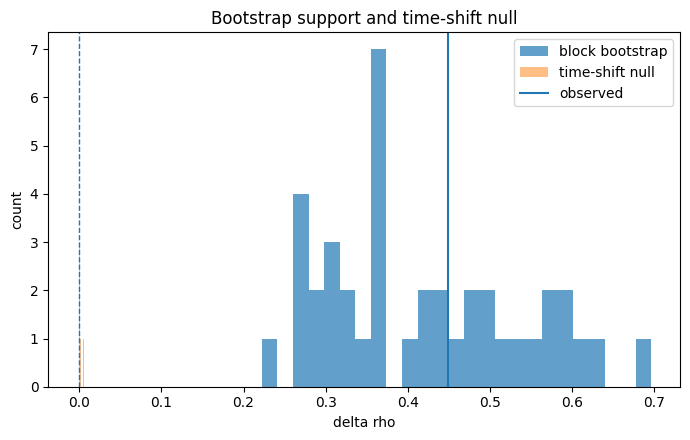

In [12]:

# =============================================================================
# INSPECT STRONGEST DESIGN
# =============================================================================

best_idx = results["delta_rho"].idxmax()
best_row = results.loc[best_idx]
best_id = best_row["design_id"]
det = details_store[best_id]

print("Strongest design by delta rho:")
display(best_row.to_frame("value"))
print("\nZero-witness audit:")
display(det["zero_witness"]["table"])
print("\nBootstrap summary:")
display(det["boot_df"].describe())
print("\nTime-shift null summary:")
display(det["null_df"].describe())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(det["boot_df"]["delta_rho"].dropna(), bins=25, alpha=0.7, label="block bootstrap")
ax.hist(det["null_df"]["delta_rho_null"].dropna(), bins=25, alpha=0.5, label="time-shift null")
ax.axvline(0.0, linestyle="--", linewidth=1)
ax.axvline(best_row["delta_rho"], linestyle="-", linewidth=1.5, label="observed")
ax.set_xlabel("delta rho")
ax.set_ylabel("count")
ax.set_title("Bootstrap support and time-shift null")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "fig06_best_bootstrap_vs_null_V3.png", dpi=220)
plt.show()


In [13]:

# =============================================================================
# AUTOMATIC REPORT
# =============================================================================

summary_cols = [
    "window", "window_kind", "event_type", "q", "bin", "drive_mode",
    "drive_timing", "K", "rho_naive", "rho_drive", "delta_rho",
    "delta_rho_boot_p05", "delta_rho_boot_p95",
    "delta_rho_boot_pos_share", "rank1_delta", "kappa_median",
    "spike_ratio", "loading_alignment", "null_p_ge_observed",
    "critical_to_subcritical", "evidence_class", "alg1_applicable"
]

report = []
report.append("# Crypto common-drive event-network V3 report")
report.append("")
report.append("## Configuration")
report.append("")
report.append(f"- QUICK_MODE: {QUICK_MODE}")
report.append(f"- symbols: {', '.join(SYMBOLS)}")
report.append(f"- windows: {', '.join(w['name'] for w in WINDOWS)}")
report.append(f"- completed designs: {len(results)}")
report.append(f"- bootstrap reps per design: {BOOTSTRAP_REPS}")
report.append(f"- time-shift null reps per design: {NULL_REPS}")
report.append("")
report.append("## Main safeguards")
report.append("")
report.append("- Event indicators were excluded from all common-drive constructions.")
report.append("- Leave-one-out drives exclude the target asset.")
report.append("- Histories were reconstructed after block resampling.")
report.append("- Shock-specificity was evaluated against matched design controls.")
report.append("- Algorithm 1 was suppressed whenever zero-witness separation failed.")
report.append("")
report.append("## Design results")
report.append("")
report.append(simple_table_markdown(
    results[summary_cols].sort_values("delta_rho", ascending=False).head(30),
    index=False
))
report.append("")
report.append("## Evidence classes")
report.append("")
report.append(simple_table_markdown(
    results["evidence_class"].value_counts().rename_axis("class").reset_index(name="n"),
    index=False
))
report.append("")
report.append("## Shock-control contrasts")
report.append("")
if shock_contrasts.empty:
    report.append("_No matched shock-control contrasts were available in this run._")
else:
    contrast_cols = match_cols + [
        "window", "delta_rho", "control_delta_median",
        "shock_minus_control_median", "n_controls"
    ]
    report.append(simple_table_markdown(
        shock_contrasts[contrast_cols].sort_values(
            "shock_minus_control_median", ascending=False
        ).head(40),
        index=False
    ))
report.append("")
report.append("## Interpretation rules")
report.append("")
report.append(
    "- **False-criticality candidate:** naive radius at or above one, "
    "drive-aware radius below one, positive lower bootstrap bound, and low-rank correction."
)
report.append(
    "- **Robust common-drive deflation:** positive lower bootstrap bound, "
    "rank-one share at least 0.60, adequate kappa/spike diagnostics, "
    "and observed deflation exceeding the time-shift null."
)
report.append(
    "- **Shock-specific evidence:** shock-minus-control-median must be positive "
    "and stable across leakage-free drives and event definitions."
)
report.append(
    "- **Algorithm 1:** interpret only when alg1_applicable is True."
)
report.append("")
report.append("## Files")
report.append("")
report.append("- `tables/v3_design_results.csv`")
report.append("- `tables/v3_candidate_designs.csv`")
report.append("- `tables/v3_shock_control_contrasts.csv`")
report.append("- `figures/*.png`")

report_path = OUT / "REPORT_V3.md"
report_path.write_text("\n".join(report), encoding="utf-8")
print(report_path)
print("\n".join(report[:35]))


/Users/mauricioherrera/PycharmProjects/Proyecto-Applied-Nettwork-Science-Continuation/crypto_common_drive_event_network_pilot_package/crypto_common_drive_outputs_V3/REPORT_V3.md
# Crypto common-drive event-network V3 report

## Configuration

- QUICK_MODE: True
- symbols: BTCUSDT, ETHUSDT, BNBUSDT, SOLUSDT, XRPUSDT
- windows: FTX_collapse, Control_2022_Aug_A
- completed designs: 10
- bootstrap reps per design: 40
- time-shift null reps per design: 20

## Main safeguards

- Event indicators were excluded from all common-drive constructions.
- Leave-one-out drives exclude the target asset.
- Histories were reconstructed after block resampling.
- Shock-specificity was evaluated against matched design controls.
- Algorithm 1 was suppressed whenever zero-witness separation failed.

## Design results

| window | window_kind | event_type | q | bin | drive_mode | drive_timing | K | rho_naive | rho_drive | delta_rho | delta_rho_boot_p05 | delta_rho_boot_p95 | delta_rho_boot_pos_share | rank1_de


## Recommended execution sequence

### 1. Smoke test

```python
QUICK_MODE = True
BOOTSTRAP_REPS = 40
NULL_REPS = 20
```

This tests FTX against one control with five leakage-free designs.

### 2. Intermediate run

Keep `QUICK_MODE = False`, but temporarily set:

```python
BOOTSTRAP_REPS = 100
NULL_REPS = 50
```

Inspect candidate designs and shock-control contrasts.

### 3. Final audit

```python
QUICK_MODE = False
BOOTSTRAP_REPS = 500
NULL_REPS = 200
```

A strong applied result should satisfy all of the following:

\[
\rho_{\rm naive}\ge 1,\qquad \rho_{\rm drive}<1,
\]

\[
q_{0.05}^{*}(\Delta\rho)>0,
\qquad
\operatorname{rank1share}(\Delta)\ge 0.6,
\]

and, for crisis specificity,

\[
\Delta\rho_{\rm shock}
-
\operatorname{median}\Delta\rho_{\rm controls}>0.
\]

If the critical threshold is not crossed, the valid claim is **low-rank common-drive deflation**, not false criticality. If zero-witness separation fails, report the structural correction as **not identified**.



# Confirmatory inference for the crypto audit

This section upgrades the exploratory \(B=40\), \(N_{\rm null}=20\) calculations to
manuscript-level inference.

For each completed design, the notebook uses the full event matrix \(Y\) and the
equation-specific common-drive matrix \(M\). A block bootstrap resamples circular blocks
of \((Y,M)\), then reconstructs the filtered histories \(H^*\). This is essential:
resampling already-computed histories would make them incompatible with the resampled
event sequence.

The circular-shift null rotates the complete drive matrix by the same nontrivial shift.
It preserves:

- the temporal dependence of every drive column;
- the cross-sectional relationship among drive columns;
- the event streams and their filtered histories;

while destroying the temporal alignment between common activity and the events.

The reported Monte Carlo \(p\)-value is

\[
p=\frac{1+\#\{\Delta\rho_{\rm null}\ge\Delta\rho_{\rm obs}\}}{N+1},
\]

whose minimum at \(N=500\) is \(1/501\approx0.001996\).

Finally, the rank-one geometry is given a bootstrap confidence interval and compared
against random \(K\times K\) Gaussian perturbations. The latter is a dimension-matched
reference distribution, not a universal null model for network estimation.


In [ ]:

# =============================================================================
# CONFIRMATORY CONFIGURATION
# =============================================================================

CONFIRM_BOOT_REPS = 500
CONFIRM_NULL_REPS = 500
CONFIRM_RANK1_NULL_REPS = 5000
CONFIRM_BLOCK_MINUTES = 60
CONFIRM_MIN_SHIFT_MINUTES = 120
CONFIRM_SEED = 20260713

CONFIRM_OUT = OUT / "confirmatory"
CONFIRM_OUT.mkdir(parents=True, exist_ok=True)

print("Confirmatory bootstrap reps:", CONFIRM_BOOT_REPS)
print("Confirmatory shift-null reps:", CONFIRM_NULL_REPS)
print("Rank-one Gaussian-null reps:", CONFIRM_RANK1_NULL_REPS)


In [ ]:

# =============================================================================
# EXACT V3-COMPATIBLE CONFIRMATORY FITTING
# =============================================================================

def _minutes_per_bin(bin_size):
    if bin_size == "1min":
        return 1
    if bin_size == "5min":
        return 5
    try:
        return max(1, int(pd.Timedelta(bin_size).total_seconds() / 60))
    except Exception:
        raise ValueError(f"Unsupported bin size: {bin_size}")

def fit_confirmatory_design(Y_full, M_full, lags, half_life):
    """
    Fit the exact V3 network estimators after reconstructing filtered histories.

    Parameters
    ----------
    Y_full : array, shape (T,K)
        Event indicators/counts before dropping initial lags.
    M_full : array, shape (T,K)
        Equation-specific common drives. Column z enters equation z.
    """
    Y_full = np.asarray(Y_full, dtype=float)
    M_full = np.asarray(M_full, dtype=float)
    if Y_full.shape != M_full.shape:
        raise ValueError(
            f"Y_full and M_full must have identical T x K shape; "
            f"got {Y_full.shape} and {M_full.shape}."
        )

    H_full = build_filtered_histories(
        Y_full, lags=int(lags), half_life=float(half_life)
    )
    sl = slice(int(lags), None)
    naive = fit_network(Y_full[sl], H_full[sl], M=None)
    drive = fit_network(Y_full[sl], H_full[sl], M=M_full[sl])

    Bn = naive["B"]
    Bd = drive["B"]
    return {
        "rho_naive": spectral_radius(Bn),
        "rho_drive": spectral_radius(Bd),
        "delta_rho": spectral_radius(Bn) - spectral_radius(Bd),
        "B_naive": Bn,
        "B_drive": Bd,
        "rank1_share": rank1_share(Bn - Bd),
    }

def circular_moving_block_indices(T, block_length, rng):
    """Circular moving-block indices of exact total length T."""
    L = max(2, min(int(block_length), int(T)))
    idx = []
    while len(idx) < T:
        start = int(rng.integers(0, T))
        idx.extend(((start + np.arange(L)) % T).tolist())
    return np.asarray(idx[:T], dtype=int)

def confirmatory_block_bootstrap(
    Y_full, M_full, lags, half_life, block_length,
    reps=CONFIRM_BOOT_REPS, seed=CONFIRM_SEED,
):
    """
    Resample blocks of (Y,M), reconstruct H, and refit the exact V3 estimators.
    One bootstrap pass supplies both delta-rho and rank-one-share uncertainty.
    """
    rng = np.random.default_rng(seed)
    Y_full = np.asarray(Y_full, dtype=float)
    M_full = np.asarray(M_full, dtype=float)
    T = len(Y_full)
    rows = []

    for b in range(int(reps)):
        ii = circular_moving_block_indices(T, block_length, rng)
        fit = fit_confirmatory_design(
            Y_full[ii], M_full[ii], lags=lags, half_life=half_life
        )
        rows.append({
            "rep": b,
            "rho_naive": fit["rho_naive"],
            "rho_drive": fit["rho_drive"],
            "delta_rho": fit["delta_rho"],
            "rank1_share": fit["rank1_share"],
        })

    return pd.DataFrame(rows)

def confirmatory_circular_shift_null(
    Y_full, M_full, lags, half_life, min_shift,
    reps=CONFIRM_NULL_REPS, seed=CONFIRM_SEED + 100000,
):
    """
    Rotate the full T x K drive matrix by one common shift.

    A common shift preserves the cross-sectional relationship among equation-specific
    drives while destroying their alignment with the event histories.
    """
    rng = np.random.default_rng(seed)
    Y_full = np.asarray(Y_full, dtype=float)
    M_full = np.asarray(M_full, dtype=float)
    T = len(Y_full)

    if T <= 2 * min_shift + 1:
        raise ValueError("Time series too short for the requested minimum shift.")

    observed = fit_confirmatory_design(
        Y_full, M_full, lags=lags, half_life=half_life
    )
    rows = []
    for b in range(int(reps)):
        shift = int(rng.integers(int(min_shift), T - int(min_shift)))
        M_shift = np.roll(M_full, shift=shift, axis=0)
        fit = fit_confirmatory_design(
            Y_full, M_shift, lags=lags, half_life=half_life
        )
        rows.append({
            "rep": b,
            "shift": shift,
            "delta_rho_null": fit["delta_rho"],
            "rank1_share_null_shift": fit["rank1_share"],
        })

    null_df = pd.DataFrame(rows)
    p_value = (
        1 + np.sum(null_df["delta_rho_null"] >= observed["delta_rho"])
    ) / (len(null_df) + 1)

    return observed, null_df, {
        "null_p_value": float(p_value),
        "null_p_floor": float(1.0 / (len(null_df) + 1)),
        "null_delta_mean": float(null_df["delta_rho_null"].mean()),
        "null_delta_p95": float(null_df["delta_rho_null"].quantile(0.95)),
    }

def gaussian_rank1_null(K, reps=CONFIRM_RANK1_NULL_REPS, seed=CONFIRM_SEED + 200000):
    """
    Dimension-matched reference distribution for rank-one energy share.
    """
    rng = np.random.default_rng(seed)
    vals = np.empty(int(reps), dtype=float)
    for b in range(int(reps)):
        vals[b] = rank1_share(rng.normal(size=(int(K), int(K))))
    return vals


In [ ]:

# =============================================================================
# BUILD CONFIRMATORY DESIGN OBJECTS FROM THE COMPLETED V3 GRID
# =============================================================================

def build_confirmatory_designs(results_df, details_dict):
    required = {
        "design_id", "lags", "half_life", "bin", "window", "event_type",
        "drive_mode", "drive_timing"
    }
    missing = required.difference(results_df.columns)
    if missing:
        raise KeyError(f"results is missing required columns: {sorted(missing)}")

    designs = {}
    for _, row in results_df.iterrows():
        did = row["design_id"]
        if did not in details_dict:
            continue
        det = details_dict[did]
        Y_df = det["Y_df"]
        M_df = det["M_df"]
        if not Y_df.index.equals(M_df.index):
            M_df = M_df.reindex(Y_df.index)
        if M_df.isna().any().any():
            raise ValueError(f"Missing drive values after alignment for {did}")

        minutes = _minutes_per_bin(row["bin"])
        designs[did] = {
            "Y_full": Y_df.to_numpy(dtype=float),
            "M_full": M_df.to_numpy(dtype=float),
            "symbols": list(Y_df.columns),
            "lags": int(row["lags"]),
            "half_life": float(row["half_life"]),
            "block_length_bins": max(
                int(row["lags"]) + 1,
                int(np.ceil(CONFIRM_BLOCK_MINUTES / minutes)),
            ),
            "min_shift_bins": max(
                int(row["lags"]) + 1,
                int(np.ceil(CONFIRM_MIN_SHIFT_MINUTES / minutes)),
            ),
            "metadata": {
                "window": row["window"],
                "window_kind": row.get("window_kind", ""),
                "event_type": row["event_type"],
                "drive_mode": row["drive_mode"],
                "drive_timing": row["drive_timing"],
                "bin": row["bin"],
                "q": row.get("q", np.nan),
            },
        }
    return designs

CONFIRM_DESIGNS = build_confirmatory_designs(results, details_store)
print("Confirmatory designs:", len(CONFIRM_DESIGNS))
for did, obj in CONFIRM_DESIGNS.items():
    print(
        did,
        "Y/M:", obj["Y_full"].shape,
        "block bins:", obj["block_length_bins"],
        "min shift bins:", obj["min_shift_bins"],
    )


In [ ]:

# =============================================================================
# RUN B=500 / N=500 CONFIRMATORY INFERENCE
# =============================================================================

confirm_rows = []
confirm_boot_store = {}
confirm_null_store = {}
rank1_gaussian_cache = {}

for j, (did, obj) in enumerate(CONFIRM_DESIGNS.items()):
    print("\n" + "=" * 100)
    print(f"[{j+1}/{len(CONFIRM_DESIGNS)}] {did}")

    observed = fit_confirmatory_design(
        obj["Y_full"], obj["M_full"],
        lags=obj["lags"], half_life=obj["half_life"]
    )

    boot = confirmatory_block_bootstrap(
        obj["Y_full"], obj["M_full"],
        lags=obj["lags"], half_life=obj["half_life"],
        block_length=obj["block_length_bins"],
        reps=CONFIRM_BOOT_REPS,
        seed=CONFIRM_SEED + 1000 * j,
    )

    observed_shift, null_df, null_summary = confirmatory_circular_shift_null(
        obj["Y_full"], obj["M_full"],
        lags=obj["lags"], half_life=obj["half_life"],
        min_shift=obj["min_shift_bins"],
        reps=CONFIRM_NULL_REPS,
        seed=CONFIRM_SEED + 100000 + 1000 * j,
    )

    K = obj["Y_full"].shape[1]
    if K not in rank1_gaussian_cache:
        rank1_gaussian_cache[K] = gaussian_rank1_null(
            K, reps=CONFIRM_RANK1_NULL_REPS,
            seed=CONFIRM_SEED + 200000 + K
        )
    r1_null = rank1_gaussian_cache[K]
    r1_p = (1 + np.sum(r1_null >= observed["rank1_share"])) / (len(r1_null) + 1)

    meta = obj["metadata"]
    row = {
        "design_id": did,
        **meta,
        "K": K,
        "T_full": len(obj["Y_full"]),
        "rho_naive": observed["rho_naive"],
        "rho_drive": observed["rho_drive"],
        "delta_rho": observed["delta_rho"],
        "delta_boot_p025": float(boot["delta_rho"].quantile(0.025)),
        "delta_boot_p05": float(boot["delta_rho"].quantile(0.05)),
        "delta_boot_p50": float(boot["delta_rho"].quantile(0.50)),
        "delta_boot_p95": float(boot["delta_rho"].quantile(0.95)),
        "delta_boot_p975": float(boot["delta_rho"].quantile(0.975)),
        "delta_boot_pos_share": float((boot["delta_rho"] > 0).mean()),
        "shift_null_p": null_summary["null_p_value"],
        "shift_null_floor": null_summary["null_p_floor"],
        "shift_null_delta_mean": null_summary["null_delta_mean"],
        "shift_null_delta_p95": null_summary["null_delta_p95"],
        "rank1_share": observed["rank1_share"],
        "rank1_boot_ci_lo": float(boot["rank1_share"].quantile(0.025)),
        "rank1_boot_ci_hi": float(boot["rank1_share"].quantile(0.975)),
        "rank1_gaussian_null_p95": float(np.quantile(r1_null, 0.95)),
        "rank1_gaussian_null_p": float(r1_p),
        "rank1_exceeds_gaussian_p95": bool(
            observed["rank1_share"] > np.quantile(r1_null, 0.95)
        ),
    }
    confirm_rows.append(row)
    confirm_boot_store[did] = boot
    confirm_null_store[did] = null_df

    print(
        f"Delta rho={row['delta_rho']:+.4f} "
        f"95% CI [{row['delta_boot_p025']:+.4f}, {row['delta_boot_p975']:+.4f}] "
        f"| shift p={row['shift_null_p']:.4f} "
        f"(floor={row['shift_null_floor']:.4f})"
    )
    print(
        f"rank1={row['rank1_share']:.3f} "
        f"95% CI [{row['rank1_boot_ci_lo']:.3f}, {row['rank1_boot_ci_hi']:.3f}] "
        f"| Gaussian-null p95={row['rank1_gaussian_null_p95']:.3f}, "
        f"p={row['rank1_gaussian_null_p']:.4f}"
    )

confirmatory_results = pd.DataFrame(confirm_rows)
confirmatory_results.to_csv(
    CONFIRM_OUT / "v4_confirmatory_inference.csv", index=False
)
display(confirmatory_results.sort_values("delta_rho", ascending=False))


In [ ]:

# =============================================================================
# CONFIRMATORY FIGURES
# =============================================================================

# Delta-rho with 95% moving-block intervals
plot_c = confirmatory_results.sort_values("delta_rho").reset_index(drop=True)
labels = (
    plot_c["window"] + " | " + plot_c["event_type"].str.replace("_burst", "", regex=False)
    + " | " + plot_c["drive_mode"] + " | " + plot_c["drive_timing"]
)

fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * len(plot_c))))
y = np.arange(len(plot_c))
xerr = np.vstack([
    plot_c["delta_rho"] - plot_c["delta_boot_p025"],
    plot_c["delta_boot_p975"] - plot_c["delta_rho"],
])
ax.errorbar(plot_c["delta_rho"], y, xerr=xerr, fmt="o", capsize=3)
ax.axvline(0.0, linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Spectral deflation, delta rho")
ax.set_title("Confirmatory moving-block bootstrap intervals")
fig.tight_layout()
fig.savefig(CONFIRM_OUT / "fig_confirm_delta_rho_ci.pdf")
fig.savefig(CONFIRM_OUT / "fig_confirm_delta_rho_ci.png", dpi=240)
plt.show()

# Rank-one share with bootstrap CI and dimension-matched Gaussian p95
fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * len(plot_c))))
rerr = np.vstack([
    plot_c["rank1_share"] - plot_c["rank1_boot_ci_lo"],
    plot_c["rank1_boot_ci_hi"] - plot_c["rank1_share"],
])
ax.errorbar(plot_c["rank1_share"], y, xerr=rerr, fmt="o", capsize=3,
            label="Observed with 95% block-bootstrap CI")
# All current designs share K=5, but draw each row's matched p95.
ax.scatter(plot_c["rank1_gaussian_null_p95"], y, marker="x",
           label="Gaussian K x K null 95th percentile")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Rank-one energy share")
ax.set_title("Low-rank geometry with uncertainty and dimension-matched reference")
ax.legend()
fig.tight_layout()
fig.savefig(CONFIRM_OUT / "fig_confirm_rank1_ci.pdf")
fig.savefig(CONFIRM_OUT / "fig_confirm_rank1_ci.png", dpi=240)
plt.show()

# Observed delta versus circular-shift reference
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    confirmatory_results["shift_null_delta_mean"],
    confirmatory_results["delta_rho"]
)
lo = min(
    confirmatory_results["shift_null_delta_mean"].min(),
    confirmatory_results["delta_rho"].min()
)
hi = max(
    confirmatory_results["shift_null_delta_mean"].max(),
    confirmatory_results["delta_rho"].max()
)
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
ax.set_xlabel("Mean circular-shift null delta rho")
ax.set_ylabel("Observed delta rho")
ax.set_title("Observed spectral deflation against temporal-alignment null")
fig.tight_layout()
fig.savefig(CONFIRM_OUT / "fig_confirm_shift_null.pdf")
fig.savefig(CONFIRM_OUT / "fig_confirm_shift_null.png", dpi=240)
plt.show()


In [ ]:

# =============================================================================
# MANUSCRIPT-READY TABLES AND TEXT
# =============================================================================

paper_cols = [
    "window", "event_type", "drive_mode", "drive_timing",
    "rho_naive", "rho_drive", "delta_rho",
    "delta_boot_p025", "delta_boot_p975",
    "shift_null_p",
    "rank1_share", "rank1_boot_ci_lo", "rank1_boot_ci_hi",
    "rank1_gaussian_null_p",
]
paper_table = confirmatory_results[paper_cols].copy()
paper_table.to_csv(
    CONFIRM_OUT / "v4_confirmatory_table_manuscript.csv", index=False
)

# Markdown table
md_table = paper_table.to_markdown(index=False, floatfmt=".4f")
(CONFIRM_OUT / "v4_confirmatory_table.md").write_text(
    md_table, encoding="utf-8"
)

# LaTeX table; escape is disabled to retain readable labels.
latex_table = paper_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    escape=True,
    caption=(
        "Confirmatory inference for leakage-free crypto event networks. "
        "Intervals are 95\\% circular moving-block bootstrap intervals "
        f"with B={CONFIRM_BOOT_REPS}; p-values use "
        f"N={CONFIRM_NULL_REPS} circular shifts with continuity correction."
    ),
    label="tab:crypto-confirmatory",
)
(CONFIRM_OUT / "v4_confirmatory_table.tex").write_text(
    latex_table, encoding="utf-8"
)

# Short manuscript-ready paragraph with values filled automatically.
n_designs = len(confirmatory_results)
n_delta_ci_positive = int((confirmatory_results["delta_boot_p025"] > 0).sum())
n_shift_below_005 = int((confirmatory_results["shift_null_p"] < 0.05).sum())
n_rank1_above = int(confirmatory_results["rank1_exceeds_gaussian_p95"].sum())

paragraph = f"""
Confirmatory inference used {CONFIRM_BOOT_REPS} circular moving-block bootstrap
replicates and {CONFIRM_NULL_REPS} circular-shift null replicates for each of
{n_designs} pre-specified designs. The 95% bootstrap interval for spectral
deflation excluded zero in {n_delta_ci_positive} designs. The temporal-alignment
null yielded p<0.05 in {n_shift_below_005} designs, with a minimum attainable
Monte Carlo p-value of {1/(CONFIRM_NULL_REPS+1):.4f}. The observed rank-one
energy share exceeded the 95th percentile of a dimension-matched Gaussian-matrix
reference in {n_rank1_above} designs. These results quantify both the magnitude
and the predominantly low-dimensional geometry of the removed network component;
they do not imply point identification when the zero-anchor audit fails.
""".strip()

(CONFIRM_OUT / "v4_confirmatory_manuscript_paragraph.txt").write_text(
    paragraph, encoding="utf-8"
)
print(paragraph)
print("\nSaved confirmatory outputs to:", CONFIRM_OUT)



## Interpretation checklist

Use the confirmatory outputs according to the following hierarchy.

1. A positive bootstrap interval for \(\Delta\rho\) supports reproducible spectral
   deflation under the fitted common-drive specification.
2. A small circular-shift \(p\)-value shows that the observed reduction is not
   reproduced when the drive's temporal alignment is destroyed.
3. A rank-one share above the dimension-matched Gaussian reference supports a
   structured low-dimensional correction, rather than relying on a large point
   estimate alone.
4. None of these results, separately or jointly, substitutes for the zero-anchor
   separation condition required for point identification of \(B_0\).
5. The Gaussian perturbation reference addresses the finite-\(K\) concern that
   an arbitrary \(5\times5\) matrix may have a moderately large leading singular
   component. It should be described as a dimension-matched reference, not as
   the unique null distribution implied by the event model.
